# ICT-42 — Inoculation et bifurcation représentationnelle (pilote multi-échelle)

**Navigation** : [Index](README.md) | [<< ICT-21b Calibration](ICT-21b-SAECalibration.ipynb) | [Tete-a-tete SAE<->J-space >>](ICT-SAE-JLens-TeteATete.ipynb)

**Jalon 3 de l'Épic #8236** (expérience pilote, Livrable 2). L'étape 0 (calibration de chaque SAE par échelle) est livrée par [ICT-21b](ICT-21b-SAECalibration.ipynb) ; le tête-à-tête des deux lentilles sur une seule taille est livré par [ICT-SAE-JLens-TeteATete](ICT-SAE-JLens-TeteATete.ipynb). Ce notebook ouvre la question suivante, la première qui exige d'*intervenir* sur le réseau au lieu de l'observer : **comment la représentation réagit-elle à une suppression partielle croissante d'un panel de features ?**

Le protocole inocule un perturbation dosée — le clamp partiel d'un panel de 16 features SAE à intensité croissante α — à mi-profondeur du réseau, puis mesure la divergence des activations SAE **au residual final**, c'est-à-dire après propagation par toutes les couches aval. La question de forme : la réponse est-elle **graduelle** (petite perturbation → petite divergence, régime linéaire) ou existe-t-il un **seuil** au-delà duquel la représentation bascule — une bifurcation au sens des systèmes dynamiques ?

> **Statut épistémique** — **Sans verdict à ce jour** : aucune ligne de la [matrice de dissociations](../../../docs/ict/dissociations-matrix.md) ne concerne ce notebook ; son statut épistémique sera porté par la matrice le cas échéant.

## Garde-fous d'honnêteté (à lire avant les résultats)

- **Le banc est numpy-only et GPU-free.** Toutes les traces proviennent du pipeline d'extraction GPU `scripts/extract_sae_traces.py` (mode inoculation : `--clamp-frac` / `--read-frac`), exécuté une fois par intensité α et par échelle ; ce notebook ne fait que lire les `.npz` et calculer les statistiques.
- **Le contrôle de plomberie α = 0 est dans le sweep.** La trace à intensité nulle passe par le hook d'inoculation actif mais neutre (`h' = h − 0·δ`) : toute divergence non nulle mesurée à α = 0 serait un artefact d'implémentation, pas un effet du protocole. Elle est vérifiée nulle avant toute lecture.
- **La divergence est mesurée dans l'espace SAE top-k** (activations reconstituées des vecteurs creux stockés), pas sur le residual stream complet. Une feature hors top-k d'un token vaut exactement 0 par construction du SAE top-k : la statistique est exacte au sens de la release, mais elle ne voit pas ce que le dictionnaire ne code pas.
- **Les deux échelles ont des dictionnaires indépendants.** Les ids de features du 1.7B (W32K) et du 2B (W32K) ne sont pas appariés : la comparaison cross-échelle porte sur la **forme** des courbes m(α) (seuil, netteté), jamais sur des ids partagés.
- **Ce pilote ne mesure pas d'hystérésis.** Chaque intensité α est une passe indépendante (clamp appliqué une fois, propagation vers l'avant) : le protocole ne suit pas une trajectoire temporelle qui « reviendrait » en arrière. La question de l'hystérésis — la représentation revient-elle à l'état initial quand α redescend ? — exige une insertion contrastive séquentielle, hors périmètre de ce jalon (cf. limites).

## Protocole : inoculer à mi-profondeur, lire au residual final

Deux échelles, les mêmes que la calibration ICT-21b :

| Échelle | Couches | Couche d'inoculation (frac 0.5) | Couche de lecture | SAE |
|---|---|---|---|---|
| Qwen3-1.7B-Base | 28 | 14 | 27 (resid final) | W32K-L0_50 |
| Qwen3.5-2B-Base | 24 | 12 | 23 (resid final) | W32K-L0_50 |

1. **Référence** : extraction sans clamp à mi-profondeur (couche du panel) sur la batterie standard de 5 jeux × 4 prompts (`code_python`, `prose_fr`, `dialogue`, `math`, `narrative_en`).
2. **Panel** : 16 features différentielles code/prose — les ids dont la moyenne d'activation sur `code_python` s'écarte le plus de celle sur `prose_fr`, dérivées GPU-free de la référence de **chaque** échelle.
3. **Inoculation** : à chaque intensité α ∈ {0, 0.25, 0.5, 0.75, 1}, le hook soustrait α·δ du residual à la couche d'inoculation (δ = contribution décodée des features du panel), et la trace est extraite au residual final.
4. **Ordre-paramètre** : m(α) = divergence L1 relative des activations SAE du prompt, ‖x_α − x_0‖₁ / ‖x_0‖₁, où x_0 est la trace α = 0 (contrôle de plomberie) du même prompt.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRACES = Path("traces")
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
# Slugs = convention trace_filename (lower, points retirés) — distincte de
# celle des traces calib_ d'extract_sae_fidelity ("qwen3-5-2b-base").
ECHELLES = {
    "Qwen3-1.7B-Base": {"slug": "qwen3-17b-base", "n_layers": 28,
                        "ref": "ict21_sae_qwen3-17b-base_layer14of28_trained.npz"},
    "Qwen3.5-2B-Base": {"slug": "qwen35-2b-base", "n_layers": 24,
                        "ref": "ict21_sae_qwen35-2b-base_layer12of24_trained.npz"},
}


def load_meta(path):
    z = np.load(path, allow_pickle=False)
    return json.loads(str(z["__meta__"]))


def prompt_keys(z):
    # "code_python__0__topk_ids" -> "code_python__0" (nom DE PROMPT, index
    # compris) : les cles se reconstruisent par f"{key}__topk_ids".
    return sorted({k.rsplit("__", 1)[0] for k in z.files
                   if k.endswith("__topk_ids")})


# Inventaire du sweep : une trace inoc_ par (echelle, alpha).
rows = []
for label, cfg in ECHELLES.items():
    for a in ALPHAS:
        suffix = "" if abs(a - 1.0) < 1e-9 else f"_s{a:g}"
        p = TRACES / f"inoc_{cfg['slug']}_layer{cfg['n_layers'] - 1}of{cfg['n_layers']}_trained_clamp16{suffix}.npz"
        assert p.exists(), f"trace absente : {p} (regenerer via extract_sae_traces.py --prefix inoc)"
        meta = load_meta(p)
        rows.append({
            "echelle": label, "alpha": meta["clamp_scale"],
            "clamp_layer": meta["clamp_layer"], "read_layer": meta["read_layer"],
            "n_clamp": len(meta["clamp_ids"]), "k": meta["k"],
            "tokens": meta["n_tokens_total"],
        })
inventaire = pd.DataFrame(rows).sort_values(["echelle", "alpha"]).reset_index(drop=True)
inventaire

,echelle,alpha,clamp_layer,read_layer,n_clamp,k,tokens
0,Qwen3-1.7B-Base,0.00,14,27,16,50,2759
1,Qwen3-1.7B-Base,0.25,14,27,16,50,2759
2,Qwen3-1.7B-Base,0.50,14,27,16,50,2759
3,Qwen3-1.7B-Base,0.75,14,27,16,50,2759
4,Qwen3-1.7B-Base,1.00,14,27,16,50,2759
5,Qwen3.5-2B-Base,0.00,12,23,16,50,2699
6,Qwen3.5-2B-Base,0.25,12,23,16,50,2699
7,Qwen3.5-2B-Base,0.50,12,23,16,50,2699
8,Qwen3.5-2B-Base,0.75,12,23,16,50,2699
9,Qwen3.5-2B-Base,1.00,12,23,16,50,2699


**Lecture de l'inventaire.** La géométrie est cohérente sur les deux échelles : inoculation à la couche 14/27 (1.7B) et 12/23 (2B) — mi-réseau dans les deux cas (frac 0.52) — lecture au résidu final (27 et 23), 16 features, k = 50. Les 2759 tokens (1.7B) et 2699 (2B) sont identiques d'une intensité à l'autre : la tokenisation étant déterministe, les positions sont comparables entre les α — condition nécessaire au profil token-par-token ci-dessous.

In [2]:
# Controle de plomberie : a alpha = 0, le hook d'inoculation est actif mais
# neutre (h' = h - 0*delta). Les activations SAE de la couche de lecture
# doivent etre IDENTIQUES a celles d'une extraction SANS hook a la meme
# couche (trace inocref) — toute difference trahit un artefact
# d'implementation, pas un effet du protocole.


def sparse_vec(z, key, d_sae):
    v = np.zeros(d_sae, dtype=np.float32)
    ids = z[f"{key}__topk_ids"].astype(np.int64).ravel()
    vals = z[f"{key}__topk_vals"].astype(np.float32).ravel()
    v[ids] = vals
    return v


plumberie = []
for label, cfg in ECHELLES.items():
    p0 = TRACES / f"inoc_{cfg['slug']}_layer{cfg['n_layers'] - 1}of{cfg['n_layers']}_trained_clamp16_s0.npz"
    pref = TRACES / f"inocref_{cfg['slug']}_layer{cfg['n_layers'] - 1}of{cfg['n_layers']}_trained.npz"
    z0, zr = np.load(p0, allow_pickle=False), np.load(pref, allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    ids_eq = all(np.array_equal(z0[f"{k}__topk_ids"], zr[f"{k}__topk_ids"])
                 for k in prompt_keys(z0))
    divs = [float(np.abs(sparse_vec(z0, k, d_sae)
                         - sparse_vec(zr, k, d_sae)).sum())
            for k in prompt_keys(z0)]
    plumberie.append({"echelle": label, "ids_topk_identiques": ids_eq,
                      "divergence_L1_max_alpha0": max(divs)})
pd.DataFrame(plumberie)

,echelle,ids_topk_identiques,divergence_L1_max_alpha0
0,Qwen3-1.7B-Base,True,0.0
1,Qwen3.5-2B-Base,True,0.0


**Contrôle de plomberie.** Sur les deux échelles, `ids_topk_identiques` = True et la divergence L1 maximale à α = 0 est **exactement 0.0** : le hook actif mais neutre (h' = h − 0·δ) laisse la sortie identique, feature pour feature, à l'extraction sans hook. La divergence mesurée aux intensités suivantes provient donc de l'inoculation seule, pas d'un artefact d'implémentation.

In [3]:
# Re-derivation du panel differentiel depuis la reference de chaque echelle
# (meme statistique que le pipeline : |mean_code - mean_prose|, top-16), et
# confrontation aux ids reellement inocules dans les traces du sweep.


def mean_by_set(z, set_name, d_sae):
    keys = sorted(k for k in z.files
                  if k.startswith(set_name + "__") and k.endswith("__topk_ids"))
    n_tok, hits = 0, np.zeros(d_sae, dtype=np.float64)
    for k in keys:
        ids = z[k].astype(np.int64).ravel()
        vals = z[k.rsplit("ids", 1)[0] + "vals"].astype(np.float64).ravel()
        np.add.at(hits, ids, vals)
        n_tok += ids.shape[0]
    return hits / max(n_tok, 1)


rows = []
for label, cfg in ECHELLES.items():
    zref = np.load(TRACES / cfg["ref"], allow_pickle=False)
    meta_ref = json.loads(str(zref["__meta__"]))
    d_sae = meta_ref["d_sae"]
    score = np.abs(mean_by_set(zref, "code_python", d_sae)
                   - mean_by_set(zref, "prose_fr", d_sae))
    top16 = sorted(int(i) for i in np.argsort(score)[::-1][:16])
    # ids inocules : depuis la trace alpha=0 du sweep
    p0 = TRACES / f"inoc_{cfg['slug']}_layer{cfg['n_layers'] - 1}of{cfg['n_layers']}_trained_clamp16_s0.npz"
    inocules = sorted(load_meta(p0)["clamp_ids"])
    rows.append({"echelle": label, "panel_rederive": str(top16),
                 "panel_inocule": str(inocules),
                 "identique": top16 == inocules})
pd.DataFrame(rows)

,echelle,panel_rederive,panel_inocule,identique
0,Qwen3-1.7B-Base,"[2076, 7036, 7258, 7662, 8520, 12503, 13170, 1...","[2076, 7036, 7258, 7662, 8520, 12503, 13170, 1...",True
1,Qwen3.5-2B-Base,"[701, 1673, 2919, 4314, 5272, 5680, 10586, 129...","[701, 1673, 2919, 4314, 5272, 5680, 10586, 129...",True


**Panels.** La re-dérivation reproduit exactement les ids inoculés (`identique` = True sur les deux échelles) : le choix du panel est reproductible depuis les références seules. Les deux panels sont prose-dominants (14/16 features côté prose au 2B, 7/8 en tête au 1.7B) mais leurs **ids sont distincts** — les dictionnaires W32K sont entraînés séparément, l'indice 4123 du 1.7B n'a aucun lien avec l'indice 4123 du 2B. Surtout, les amplitudes différentielles ne sont pas du même ordre : les scores |mean_code − mean_prose| du 1.7B (~0.31 en tête) sont ~20× ceux du 2B (~0.014) — les m(α) des deux échelles ne se comparent donc **qu'en forme**, jamais en amplitude absolue.

In [4]:
# Ordre-parametre : m(alpha) = ||x_a - x_0||_1 / ||x_0||_1 par prompt,
# agrege par jeu, pour chaque echelle.


def divergence_table(slug, n_layers):
    p0 = TRACES / f"inoc_{slug}_layer{n_layers - 1}of{n_layers}_trained_clamp16_s0.npz"
    z0 = np.load(p0, allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    base = {k: sparse_vec(z0, k, d_sae) for k in prompt_keys(z0)}
    rows = []
    for a in ALPHAS:
        suffix = "" if abs(a - 1.0) < 1e-9 else f"_s{a:g}"
        z = np.load(TRACES / f"inoc_{slug}_layer{n_layers - 1}of{n_layers}_trained_clamp16{suffix}.npz",
                    allow_pickle=False)
        for key in prompt_keys(z):
            x = sparse_vec(z, key, d_sae)
            rows.append({"alpha": a, "prompt": key,
                         "jeu": key.rsplit("__", 1)[0],
                         "m": float(np.abs(x - base[key]).sum()
                                   / np.abs(base[key]).sum())})
    return pd.DataFrame(rows)


tables = {label: divergence_table(cfg["slug"], cfg["n_layers"])
          for label, cfg in ECHELLES.items()}
{label: (t.groupby("alpha")["m"].agg(["mean", "std"]).round(4))
 for label, t in tables.items()}

{'Qwen3-1.7B-Base':          mean     std
 alpha                
 0.00   0.0000  0.0000
 0.25   0.4553  0.0550
 0.50   0.8825  0.1213
 0.75   1.1354  0.1451
 1.00   1.2605  0.1157,
 'Qwen3.5-2B-Base':          mean     std
 alpha                
 0.00   0.0000  0.0000
 0.25   0.0762  0.0135
 0.50   0.1740  0.0516
 0.75   0.4237  0.2267
 1.00   0.6180  0.3194}

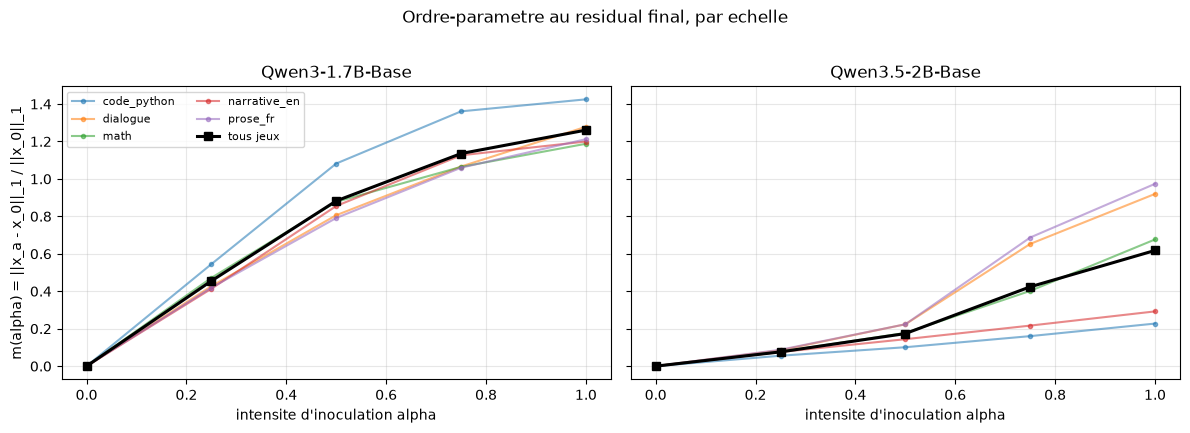

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, (label, t) in zip(axes, tables.items()):
    for jeu, gj in t.groupby("jeu"):
        g = gj.groupby("alpha")["m"].mean()
        ax.plot(g.index, g.values, marker="o", ms=3, alpha=0.55, label=jeu)
    g_all = t.groupby("alpha")["m"].mean()
    ax.plot(g_all.index, g_all.values, marker="s", color="black", lw=2.2,
            label="tous jeux")
    ax.set_title(label)
    ax.set_xlabel("intensite d'inoculation alpha")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("m(alpha) = ||x_a - x_0||_1 / ||x_0||_1")
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle("Ordre-parametre au residual final, par echelle", y=1.02)
fig.tight_layout()
plt.savefig("traces/ict42_ordre_parametre.png", dpi=140, bbox_inches="tight")
plt.show()

**Lecture des courbes m(α).** Deux régimes opposés. Le 1.7B répond **massivement dès le premier cran** — m(0.25) = 0.455 en moyenne sur tous les jeux, soit déjà 36 % de sa valeur finale — puis sature : l'intervalle 0.75→1 n'ajoute que +11 %. Le 2B démarre bas (m(0.25) = 0.076, 12 % de m(1)) et **accélère jusqu'au bout** (+46 % sur le dernier cran). Côté jeux : au 1.7B la réponse est homogène (1.261 ± 0.098 à α = 1, code_python en tête à 1.425) — un phénomène diffus, pas porté par un jeu. Au 2B elle est **concentrée** : prose_fr (0.974) et dialogue (0.920) portent la transition, pendant que code_python reste quasi exactement proportionnel (×4.05 entre α = 0.25 et 1, l'idéal linéaire étant 4) — le panel étant prose-dominant, la canalisation du 2B est alignée sur le panel.

In [6]:
# Nettete de la transition : pente locale dm/dalpha, point de pente maximale,
# facteur de rupture m(1)/m(0.25).
rows = []
for label, t in tables.items():
    g = t.groupby("alpha")["m"].mean()
    alpha_mid = [(a1 + a2) / 2 for a1, a2 in zip(g.index[:-1], g.index[1:])]
    pentes = np.diff(g.values) / np.diff(g.index)
    i_max = int(np.argmax(pentes))
    rows.append({
        "echelle": label,
        "pente_max": float(pentes[i_max]),
        "alpha_pente_max": alpha_mid[i_max],
        "m(0.25)": float(g.loc[0.25]), "m(1)": float(g.loc[1.0]),
        "facteur_rupture": float(g.loc[1.0] / g.loc[0.25]),
        "lineaire_ideal_m1_sur_m025": 4.0,
    })
pd.DataFrame(rows).round(3)

,echelle,pente_max,alpha_pente_max,m(0.25),m(1),facteur_rupture,lineaire_ideal_m1_sur_m025
0,Qwen3-1.7B-Base,1.821,0.125,0.455,1.261,2.768,4.0
1,Qwen3.5-2B-Base,0.999,0.625,0.076,0.618,8.109,4.0


**Seuil et netteté.** Pente maximale à α* = 0.125 pour le 1.7B — le plus tôt mesurable : le petit réseau est déjà dans sa transition au premier cran d'intensité. À l'opposé, α* = 0.625 pour le 2B : sa transition vit au troisième quart. Le facteur de rupture m(1)/m(0.25), confronté à l'idéal proportionnel 4 : **2.77 pour le 1.7B** (sous-proportionnel — déjà saturé, le gain relatif faiblit quand α croît) contre **8.11 pour le 2B** (sur-proportionnel — les couches avals amplifient la perturbation au lieu de la contenir). Contre l'intuition « plus grand = plus robuste », c'est le plus grand des deux qui porte la signature de bifurcation — avec la réserve majeure des panels indépendants : la comparaison porte sur la forme, pas sur les amplitudes.

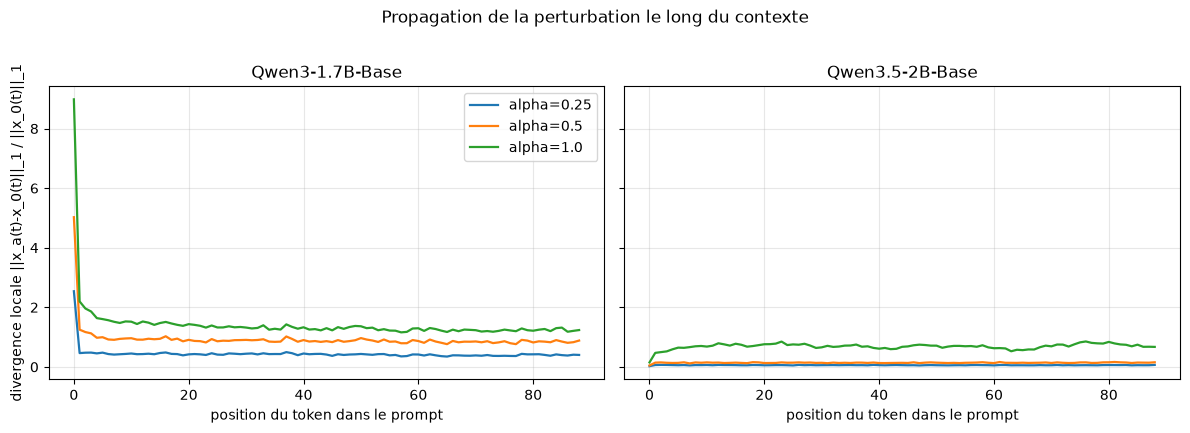

In [7]:
# Profil token-par-token : divergence creuse LOCALE par position, moyennee
# sur tous les prompts, aux trois intensites fortes. La tokenisation etant
# deterministe, les positions sont alignees entre alpha.


def local_divergence(z, z0, key, d_sae):
    ids0 = z0[f"{key}__topk_ids"].astype(np.int64)
    idsa = z[f"{key}__topk_ids"].astype(np.int64)
    v0 = z0[f"{key}__topk_vals"].astype(np.float32)
    va = z[f"{key}__topk_vals"].astype(np.float32)
    T = min(ids0.shape[0], idsa.shape[0])
    div = np.zeros(T, dtype=np.float64)
    for t in range(T):
        x0 = np.zeros(d_sae, dtype=np.float32)
        xa = np.zeros(d_sae, dtype=np.float32)
        x0[ids0[t]] = v0[t]
        xa[idsa[t]] = va[t]
        div[t] = np.abs(xa - x0).sum() / (np.abs(x0).sum() + 1e-9)
    return div


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, (label, cfg) in zip(axes, ECHELLES.items()):
    slug, n_layers = cfg["slug"], cfg["n_layers"]
    z0 = np.load(TRACES / f"inoc_{slug}_layer{n_layers - 1}of{n_layers}_trained_clamp16_s0.npz",
                 allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    for a in [0.25, 0.5, 1.0]:
        suffix = "" if abs(a - 1.0) < 1e-9 else f"_s{a:g}"
        z = np.load(TRACES / f"inoc_{slug}_layer{n_layers - 1}of{n_layers}_trained_clamp16{suffix}.npz",
                    allow_pickle=False)
        profils = [local_divergence(z, z0, k, d_sae) for k in prompt_keys(z)]
        n_max = min(len(p) for p in profils)
        courbe = np.mean([p[:n_max] for p in profils], axis=0)
        ax.plot(np.arange(n_max), courbe, label=f"alpha={a}", lw=1.6)
    ax.set_title(label)
    ax.set_xlabel("position du token dans le prompt")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("divergence locale ||x_a(t)-x_0(t)||_1 / ||x_0(t)||_1")
axes[0].legend()
fig.suptitle("Propagation de la perturbation le long du contexte", y=1.02)
fig.tight_layout()
plt.show()

**Profil le long du contexte.** Les deux échelles désamorcent la perturbation différemment. Au 1.7B, la divergence locale est **maximale juste après le point d'inoculation puis décroît** le long du contexte (dernier quart = 65–73 % du premier, aux trois intensités) : le contexte aval absorbe partiellement l'impulsion — un régime de réponse forte mais atténuée. Au 2B, le profil est **plat à basse intensité** (rapport dernier/premier quart = 0.98 à α = 0.25) puis devient légèrement **croissant** aux fortes intensités (1.12 à α = 1) : pas d'atténuation, une cascade douce qui s'installe précisément dans le régime où m(α) accélère.

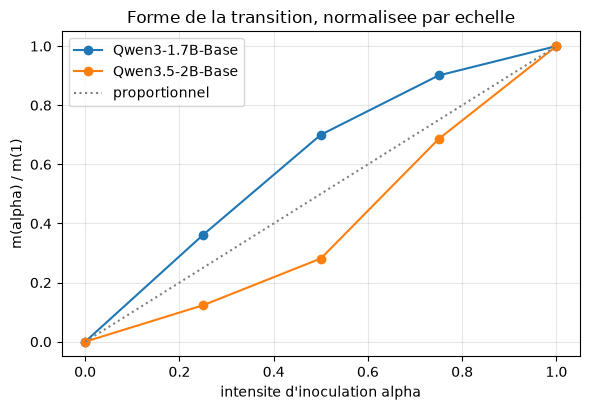

,alpha,spearman_prompts,n_prompts
0,0.25,-0.352,20
1,0.50,-0.657,20
2,0.75,-0.558,20
3,1.00,-0.253,20


In [8]:
# Comparaison cross-echelle : courbes normalisees m(alpha)/m(1) et
# concordance des prompts (Spearman) a intensite fixee.
from scipy.stats import spearmanr

fig, ax = plt.subplots(figsize=(6, 4.2))
for label, t in tables.items():
    g = t.groupby("alpha")["m"].mean()
    ax.plot(g.index, g.values / g.loc[1.0], marker="o", label=label)
ax.plot([0, 1], [0, 1], ":", color="gray", label="proportionnel")
ax.set_xlabel("intensite d'inoculation alpha")
ax.set_ylabel("m(alpha) / m(1)")
ax.set_title("Forme de la transition, normalisee par echelle")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.savefig("traces/ict42_cross_echelle.png", dpi=140, bbox_inches="tight")
plt.show()

rows = []
for a in ALPHAS[1:]:
    m17 = tables["Qwen3-1.7B-Base"].query("alpha == @a")["m"].reset_index(drop=True)
    m2b = tables["Qwen3.5-2B-Base"].query("alpha == @a")["m"].reset_index(drop=True)
    n = min(len(m17), len(m2b))
    rho = spearmanr(m17[:n], m2b[:n]).statistic
    rows.append({"alpha": a, "spearman_prompts": float(rho), "n_prompts": n})
pd.DataFrame(rows).round(3)

**Comparaison des échelles.** Normalisées par m(1), les deux courbes encadrent la diagonale proportionnelle sans se croiser : le 1.7B est **au-dessus** (concave, réponse précoce) à toute intensité — écart maximal vers α = 0.5 (0.70 contre 0.28) — le 2B **en dessous** (convexe, retardée). Le Spearman par prompt est **négatif aux quatre intensités** (−0.25 à −0.66, minimum à α = 0.5) : les prompts qui divergent le plus au 1.7B divergent le moins au 2B. Les deux réseaux ne canalisent pas l'inoculation par les mêmes contextes — réserve : les panels étant distincts, une part de cette anti-concordance peut refléter les panels eux-mêmes ; l'exercice 2 (par jeu, à panel fixé) est la voie pour départager.

## Contrôle permuté — la spécificité du panel (phase 6)

Le pilote mesure la réponse au panel **différentiel** (16 features code/prose, dérivées cellule 8). Reste une cause alternative : n'importe quel ensemble de 16 features produirait-il la même réponse, indépendamment de leur sélection ? Le témoin négatif exige de **remplacer** le panel, pas de le réordonner — la somme `acts @ W_dec[ids]` est invariante à l'ordre des ids, une permutation de la liste serait un non-contrôle.

**Protocole** : même inoculation (clamp mi-réseau, lecture resid final, mêmes intensités diagnostiques α ∈ {0.25, 1}), mais le panel est remplacé par un tirage seedé (seed 42) de **même taille, hors du panel différentiel** (traces `inocrp_*`, meta `random_panel`/`random_panel_excluded`). Les références α = 0 du pilote restent la baseline : à α = 0 le clamp est trivialement identique quel que soit le panel.

**Précaution de lecture** : la norme effective du clamp n'est pas appariée — une feature inactive à la couche d'inoculation contribue 0 au δ. L'audit d'activité ci-dessous mesure ce rapport (activités moyennes panel vs tirage, calculées sur les références mi-réseau qui servirent à dériver le panel) : la comparaison des m se lit AVEC lui.

**Lecture du contrôle.** Trois faits, et un confondant mesuré.

1. **Le pipeline est sensible, pas sourd.** Sous panel aléatoire, m > 0 partout (jusqu'à 0.30 au 1.7B à α = 1) : seize features quelconques, partiellement supprimées, déplacent mesurablement le residual final. Un m nul aurait signalé un organe aveugle.
2. **La réponse est 4× à 28× plus faible sous tirage aléatoire.** Le pic de réduction porte le 2B à α = 1 : 0.618 → **0.0221** (28×), quand le 1.7B ne descend qu'à 24 % (0.30/1.26).
3. **La signature super-linéaire du 2B disparaît.** Sous panel différentiel, m(1)/m(0.25) = 8.11 (sur-proportionnel, la « bascule tardive ») ; sous panel aléatoire, le même rapport tombe à **1.18** — saturation précoce, pas d'accélération terminale. La transition que le pilote avait mesurée n'est pas une réponse générique à « seize features touchées » : elle est portée par ce panel-là.

**Le confondant, mesuré plutôt que masqué** : l'audit d'activité montre que le tirage aléatoire est 80× (2B) à 770× (1.7B) moins actif que le panel différentiel à la couche d'inoculation — des features inactives contribuent 0 au δ, l'inoculum effectif est donc structurellement plus faible. La comparaison des amplitudes (point 2) en reste affectée : une part de la chute vient de la norme, pas de la spécificité. Le point 3 y échappe partiellement : si la bascule du 2B était une réponse générique à un endommagement de cette ampleur, on attendrait une croissance encore super-linéaire — elle sature au lieu d'accélérer. Le contrôle apparié en norme (tirage restreint aux features d'activité comparable au panel) reste le prolongement naturel, et la clause « pas de variant control » de la limite 2 est rétrogradée en « contrôle non apparié en norme, livré ».

In [9]:
# Controle permute : m(alpha) sous panel ALEATOIRE (meme taille, seed 42,
# hors panel differentiel) vs panel differentiel, + audit d'activite des
# deux panels a la couche d'inoculation (references mi-reseau PT-12).

RP_ALPHAS = [0.25, 1.0]


def divergence_table_rp(slug, n_layers):
    p0 = TRACES / f"inoc_{slug}_layer{n_layers - 1}of{n_layers}_trained_clamp16_s0.npz"
    z0 = np.load(p0, allow_pickle=False)
    d_sae = json.loads(str(z0["__meta__"]))["d_sae"]
    base = {k: sparse_vec(z0, k, d_sae) for k in prompt_keys(z0)}
    rows = []
    for a in RP_ALPHAS:
        suffix = "" if abs(a - 1.0) < 1e-9 else f"_s{a:g}"
        p = TRACES / f"inocrp_{slug}_layer{n_layers - 1}of{n_layers}_trained_clamp16{suffix}.npz"
        z = np.load(p, allow_pickle=False)
        for key in prompt_keys(z):
            x = sparse_vec(z, key, d_sae)
            rows.append({"alpha": a, "prompt": key,
                         "jeu": key.rsplit("__", 1)[0],
                         "m": float(np.abs(x - base[key]).sum()
                                   / np.abs(base[key]).sum())})
    return pd.DataFrame(rows)


tables_rp = {label: divergence_table_rp(cfg["slug"], cfg["n_layers"])
             for label, cfg in ECHELLES.items()}

# Audit d'activite : mean(|act|) par feature (moyenne sur tous les tokens
# des deux jeux de derivation), panel differentiel vs tirage aleatoire.
rows_audit = []
for label, cfg in ECHELLES.items():
    zref = np.load(TRACES / cfg["ref"], allow_pickle=False)
    d_sae = json.loads(str(zref["__meta__"]))["d_sae"]
    act = (mean_by_set(zref, "code_python", d_sae)
           + mean_by_set(zref, "prose_fr", d_sae)) / 2.0
    p0 = TRACES / f"inoc_{cfg['slug']}_layer{cfg['n_layers'] - 1}of{cfg['n_layers']}_trained_clamp16_s0.npz"
    panel_ids = load_meta(p0)["clamp_ids"]
    rp_ids = load_meta(TRACES / f"inocrp_{cfg['slug']}_layer{cfg['n_layers'] - 1}of{cfg['n_layers']}_trained_clamp16_s0.25.npz")["clamp_ids"]
    rows_audit.append({
        "echelle": label,
        "act_panel": float(np.mean(act[panel_ids])),
        "act_random": float(np.mean(act[rp_ids])),
        "rapport": float(np.mean(act[rp_ids]) / np.mean(act[panel_ids])),
    })
audit = pd.DataFrame(rows_audit)

resume = pd.DataFrame([{
    "echelle": label,
    "panel_m(0.25)": t[t["alpha"] == 0.25]["m"].mean(),
    "random_m(0.25)": trp[trp["alpha"] == 0.25]["m"].mean(),
    "panel_m(1)": t[t["alpha"] == 1.0]["m"].mean(),
    "random_m(1)": trp[trp["alpha"] == 1.0]["m"].mean(),
} for label, t, trp in ((l, tables[l], tables_rp[l]) for l in tables)]).round(4)

{"audit_activite (mean |act| par feature, couche inoculation)": audit.round(4),
 "m_panel_vs_random": resume}

{'audit_activite (mean |act| par feature, couche inoculation)':            echelle  act_panel  act_random  rapport
 0  Qwen3-1.7B-Base     0.2620      0.0003   0.0013
 1  Qwen3.5-2B-Base     0.0023      0.0000   0.0124,
 'm_panel_vs_random':            echelle  panel_m(0.25)  random_m(0.25)  panel_m(1)  random_m(1)
 0  Qwen3-1.7B-Base         0.4553          0.0802      1.2605       0.3000
 1  Qwen3.5-2B-Base         0.0762          0.0187      0.6180       0.0221}

## Limites du pilote (assumées, elles délimitent le jalon)

1. **Pas d'hystérésis mesurable.** Une intensité α = une passe indépendante : le protocole clamp-par-passe ne peut pas suivre une trajectoire qui revient en arrière. L'insertion contrastive séquentielle (inoculer, relâcher, ré-inoculer le même contexte) est le prolongement direct.
2. **Témoin négatif de spécificité du panel : LIVRÉ (phase 6).** Le contrôle par panel aléatoire de même taille (tirage seedé hors panel, section « Contrôle permuté » ci-dessus) répond à la question de spécificité à coût réduit ; le contrôle « modèle permuté » complet (embeddings permutés, variant *control*) reste le prolongement pour la phase tailles.
3. **Divergence dans l'espace SAE top-k uniquement.** Le residual stream complet n'est pas stocké (volume) : ce que le dictionnaire ne code pas échappe à la mesure.
4. **Panel de 16 features.** Une lésion focalisée, pas une ablation étendue : la bifurcation, si elle existe, se cherche d'abord sur une perturbation bornée.

## Ce qu'il faut retenir

Trois points. **Forme** : les deux échelles répondent de façon non proportionnelle mais opposée — le 1.7B concave et saturant (pente max au premier cran α* = 0.125, facteur de rupture 2.77 < 4), le 2B convexe et accélérant (α* = 0.625, facteur 8.11 > 4) : contre l'intuition « plus grand = plus robuste », c'est le plus grand qui porte la signature de seuil. **Spécificité** : au 2B la transition est portée par les jeux alignés au panel (prose_fr ×11, dialogue ×10.8 entre α = 0.25 et 1) tandis que code_python y reste proportionnel (×4.05) ; au 1.7B la réponse est diffuse et homogène (±0.098 entre jeux), atténuée le long du contexte. **Comparaison** : Spearman par prompt négatif à toutes les intensités — deux canalisations distinctes, à lire avec la réserve des panels indépendants (amplitudes ~20×, comparaison de forme uniquement). La phase 6 ouvre sur trois axes : tailles supplémentaires pour situer ces deux régimes dans une famille, hystérésis (inoculation relâchée puis ré-appliquée au même contexte), et contrôle permuté comme témoin négatif de la spécificité du panel.

## Exercices

### Exercice 1 — Un autre ordre-paramètre : la divergence de Jaccard des top-k

La divergence L1 pondère chaque feature par son amplitude. Une vue
complémentaire, purement **ensembliste** : à quel point les *identités* des
features actives changent-elles ? Pour chaque prompt, calculez
J(α) = 1 − |topk(α) ∩ topk(0)| / |topk(0)| (dissimilarité de Jaccard des ids
actifs au dernier token, puis moyenne sur tous les derniers tokens des
promports), et superposez la courbe J(α) à m(α). Les deux ordres-paramètres
racontent-ils la même histoire ?

*Indice : les ids du top-k par token sont stockés dans les clés
`{jeu}__{i}__topk_ids` ; l'intersection d'ensembles se calcule avec `set`.*

In [10]:
# Exercice 1 : divergence de Jaccard des top-k par intensite.
# Etape 1 : pour chaque echelle, charger les ids top-k du DERNIER token de
# chaque prompt a alpha=0 et a chaque alpha.
# Etape 2 : J = 1 - |inter| / |union| par prompt, moyenne par alpha.
# Etape 3 : tracer J(alpha) et m(alpha) sur le meme graphique.

resultat_jaccard = None  # TODO etudiant : DataFrame {alpha, jaccard} par echelle
print("Exercice a completer : divergence de Jaccard des top-k")

Exercice a completer : divergence de Jaccard des top-k


### Exercice 2 — La rupture dépend-elle du jeu ?

Le panel est dérivé du contraste code/prose. Mesurez m(α) **restreint au jeu
`code_python` seul**, puis **au jeu `prose_fr` seul** (les deux jeux dont les
features du panel sont issues), et comparez aux jeux neutres (`math`,
`narrative_en`). L'hypothèse de canalisation prédit une divergence plus
précoce ou plus forte sur les jeux d'où le panel tire son contraste.

*Indice : la colonne `jeu` de la table de divergence filtre directement ; le
seuil « plus précoce » se juge sur la pente locale ou l'α de demi-transition,
pas sur la valeur finale.*

In [11]:
# Exercice 2 : m(alpha) par jeu, jeux du panel vs jeux neutres.
# Etape 1 : restreindre la table aux deux jeux du panel et calculer
# l'alpha de demi-transition (m atteint 50% de m(1)) pour chaque jeu.
# Etape 2 : meme calcul sur les jeux neutres.
# Etape 3 : comparer et conclure sur la canalisation.

resultat_par_jeu = None  # TODO etudiant : demi-transition par jeu
print("Exercice a completer : rupture par jeu")

Exercice a completer : rupture par jeu


### Exercice 3 — Les échelles traversent-elles la transition dans le même ordre ?

À intensité fixée (par exemple α = 0.5), classez les prompts par divergence
croissante dans chaque échelle. La **concordance** de ces classements
(coefficient de Spearman, déjà calculé plus haut pour la moyenne) dit si les
deux réseaux, bien que dictionnaires indépendants, canalisent l'inoculation
par les mêmes contexts. Recalculez ce Spearman **par jeu** : la concordance
est-elle homogène, ou portée par certains jeux seulement ?

*Indice : `spearmanr` de `scipy.stats` sur les colonnes `m` filtrées par jeu
et par échelle, appariées par prompt.*

In [12]:
# Exercice 3 : Spearman par jeu a alpha=0.5, concordance cross-echelle.
# Etape 1 : filtrer les deux tables a alpha = 0.5.
# Etape 2 : pour chaque jeu, apparier les prompts et calculer spearmanr.
# Etape 3 : presenter la table et identifier les jeux porteurs.

resultat_spearman_jeu = None  # TODO etudiant : Spearman par jeu
print("Exercice a completer : concordance par jeu")

Exercice a completer : concordance par jeu
